In [1446]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression,LogisticRegression 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,f1_score,r2_score

import seaborn as sns
import matplotlib.pyplot as plt

In [1447]:
df=pd.read_csv('Social_media_impact_on_life.csv')


In [1448]:
df.sample(5)

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
1604,605,22,Female,Graduate,Spain,6.3,TikTok,Yes,6.3,5.0,Negative
1627,628,20,Male,Undergraduate,USA,5.5,Twitter,Yes,6.8,6.0,Negative
193,782,18,Male,High School,Other,2.7,Snapchat,No,8.5,7.6,Positive
1010,11,19,Male,Undergraduate,France,4.8,Snapchat,Yes,6.2,5.0,Negative
112,48,23,Female,Graduate,Other,2.3,TikTok,No,8.3,8.8,Positive


In [1449]:
df.shape

(1705, 11)

In [1450]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1705 entries, 0 to 1704
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    1705 non-null   int64  
 1   Age                           1705 non-null   int64  
 2   Gender                        1705 non-null   str    
 3   Academic_Level                1705 non-null   str    
 4   Country                       1705 non-null   str    
 5   Avg_Daily_Usage_Hours         1705 non-null   float64
 6   Most_Used_Platform            1705 non-null   str    
 7   Affects_Academic_Performance  1705 non-null   str    
 8   Sleep_Hours_Per_Night         1705 non-null   float64
 9   Mental_Health_Score           1705 non-null   float64
 10  Overall_Impact                1705 non-null   str    
dtypes: float64(3), int64(2), str(6)
memory usage: 146.7 KB


In [1451]:
df.isnull().sum()

Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Overall_Impact                  0
dtype: int64

In [1452]:
df.describe()

,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,1705.000000,1705.000000,1705.000000,1705.000000,1705.000000
mean,439.510264,20.848094,5.103636,6.598710,6.215132
std,267.058174,1.758557,1.677341,1.207045,1.282678
min,1.000000,18.000000,1.500000,3.800000,4.000000
25%,214.000000,19.000000,3.800000,5.600000,5.000000
50%,427.000000,21.000000,5.100000,6.600000,6.000000
75%,640.000000,22.000000,6.300000,7.500000,7.000000
max,1000.000000,24.000000,8.500000,9.600000,9.000000


In [1453]:
df.corr(numeric_only=True)

,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
Student_ID,1.000000,0.070681,0.063552,0.003809,-0.018457
Age,0.070681,1.000000,-0.053610,0.063745,0.083701
Avg_Daily_Usage_Hours,0.063552,-0.053610,1.000000,-0.817444,-0.826391
Sleep_Hours_Per_Night,0.003809,0.063745,-0.817444,1.000000,0.785372
Mental_Health_Score,-0.018457,0.083701,-0.826391,0.785372,1.000000


In [1454]:
df.duplicated().sum()

np.int64(0)

In [1455]:
df.corr(numeric_only=True)['Mental_Health_Score']

Student_ID              -0.018457
Age                      0.083701
Avg_Daily_Usage_Hours   -0.826391
Sleep_Hours_Per_Night    0.785372
Mental_Health_Score      1.000000
Name: Mental_Health_Score, dtype: float64

# Univariate Analysis
## Visualization for Categorical 

<Axes: xlabel='Gender', ylabel='count'>

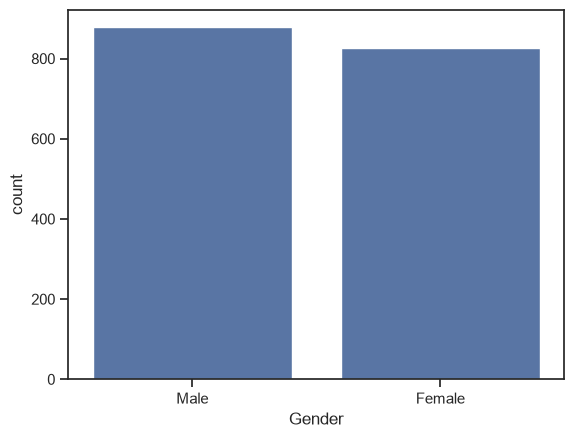

In [1456]:
sns.countplot(x=df['Gender'])

<Axes: >

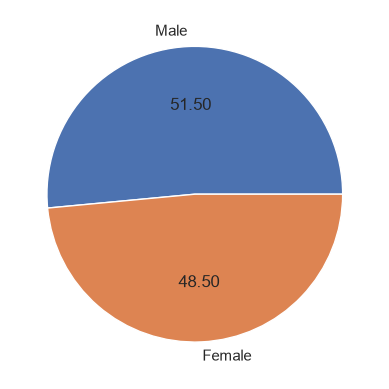

In [1457]:
df['Gender'].value_counts().plot(kind='pie',autopct='%.2f')

<Axes: xlabel='Academic_Level', ylabel='count'>

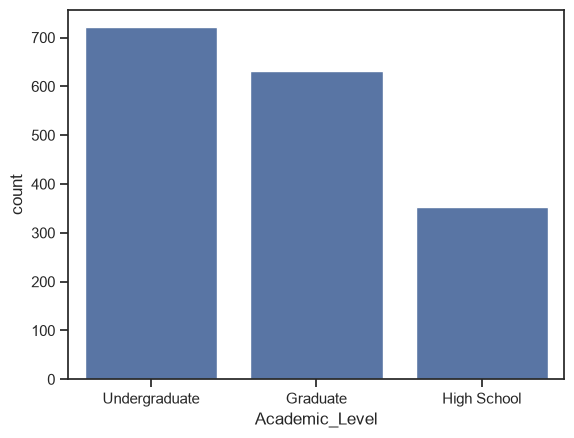

In [1458]:
sns.countplot(x=df['Academic_Level'])

C:\Users\Ahmad Qamar\AppData\Local\Temp\ipykernel_6672\2072227204.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['Most_Used_Platform'],palette='viridis')


<Axes: xlabel='count', ylabel='Most_Used_Platform'>

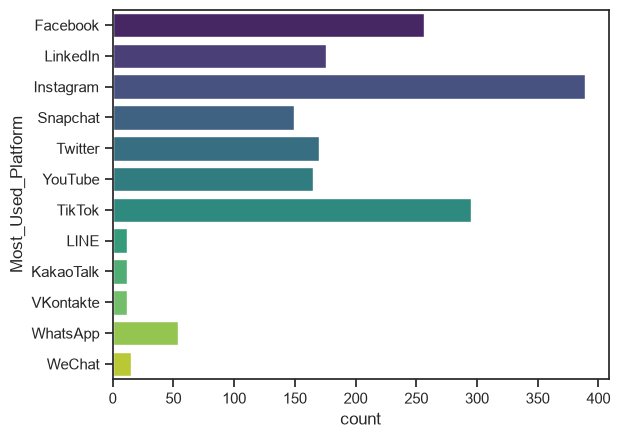

In [1459]:
sns.countplot(y=df['Most_Used_Platform'],palette='viridis')



<Axes: >

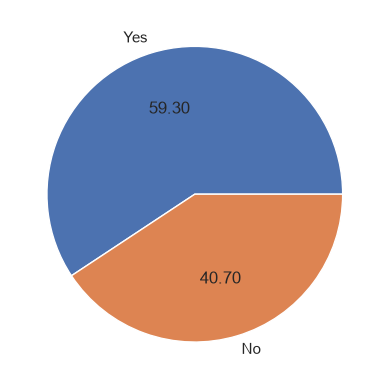

In [1460]:
df['Affects_Academic_Performance'].value_counts().plot(kind='pie',autopct='%.2f')

<Axes: >

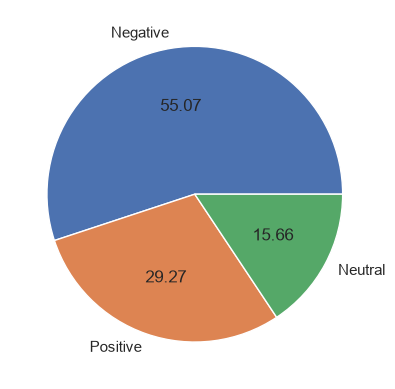

In [1461]:
df['Overall_Impact'].value_counts().plot(kind='pie',autopct='%.2f')

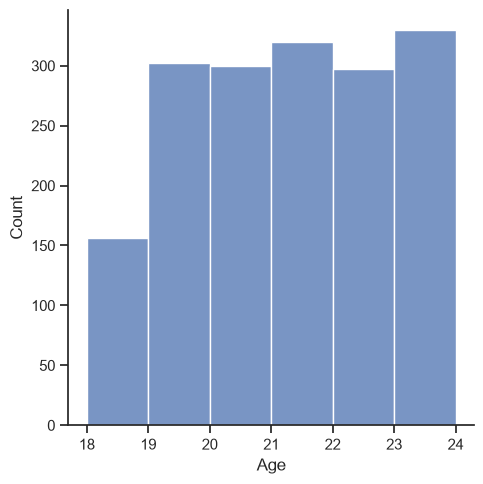

In [1462]:
sns.displot(x=df['Age'],bins=6,)

<Axes: >

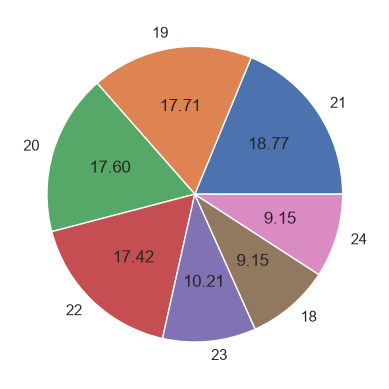

In [1463]:
df['Age'].value_counts().plot(kind='pie',autopct='%.2f')

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Count'>

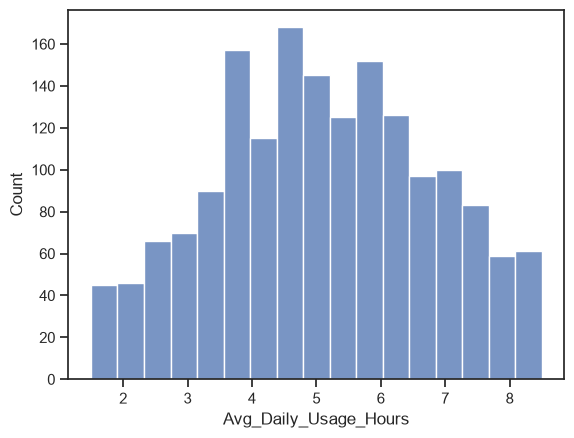

In [1464]:
plt.Figure(figsize=(10,8))
plt.xlabel('Avg_Daily_Usage_Hours')
sns.histplot(df['Avg_Daily_Usage_Hours'])


<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Count'>

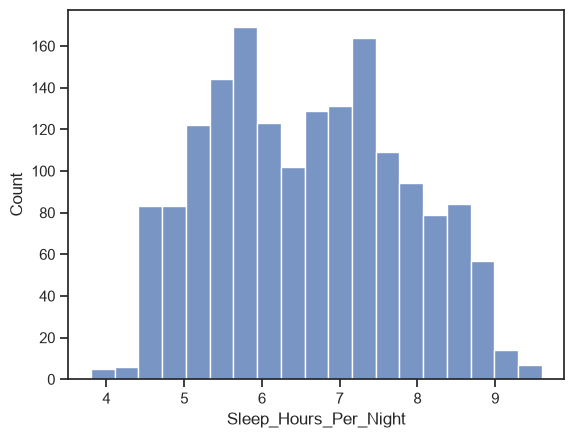

In [1465]:
sns.histplot(x=df['Sleep_Hours_Per_Night'])

<Axes: xlabel='Sleep_Hours_Per_Night'>

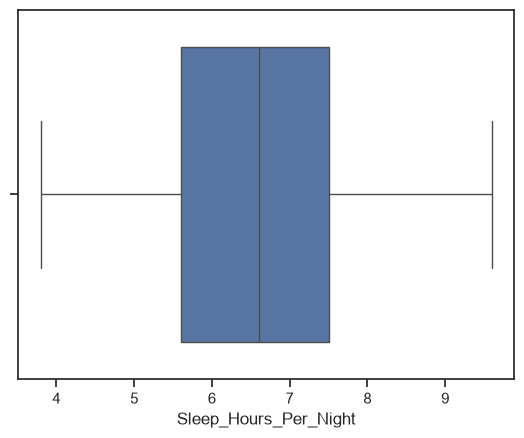

In [1466]:

sns.boxplot(x=df['Sleep_Hours_Per_Night'])

# Bivariate Analysis

In [1467]:
random=df[['Mental_Health_Score','Age']].sample(150,random_state=42)
random

,Mental_Health_Score,Age
1046,6.0,19
745,7.3,18
785,4.7,22
367,7.5,24
1029,5.0,19
...,...,...
950,6.8,20
426,4.9,24
774,5.8,18
398,4.1,20


<Axes: xlabel='Age', ylabel='Mental_Health_Score'>

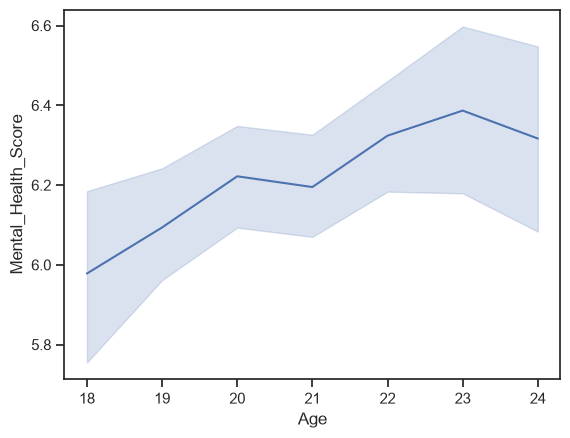

In [1468]:

sns.set_theme(style="ticks")
sns.lineplot(y=df['Mental_Health_Score'],x=df['Age'])

Text(0.5, 1.0, 'If daily usage hours increase, the mental health score tends to decrease.')

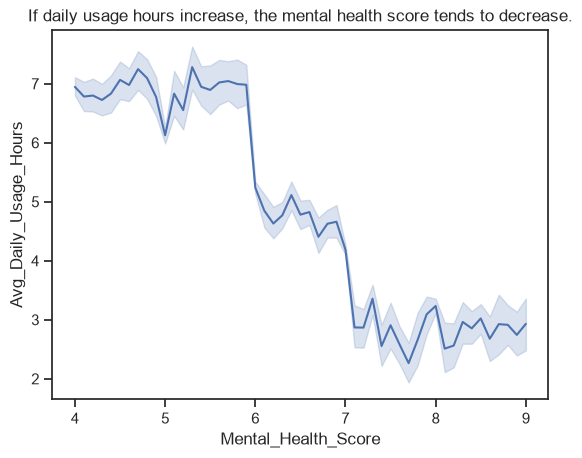

In [1469]:
sns.lineplot(x=df['Mental_Health_Score'],y=df['Avg_Daily_Usage_Hours'])
plt.title('If daily usage hours increase, the mental health score tends to decrease.')

Text(0.5, 1.0, 'If daily usage hours decrease, the mental health score tends to increase.')

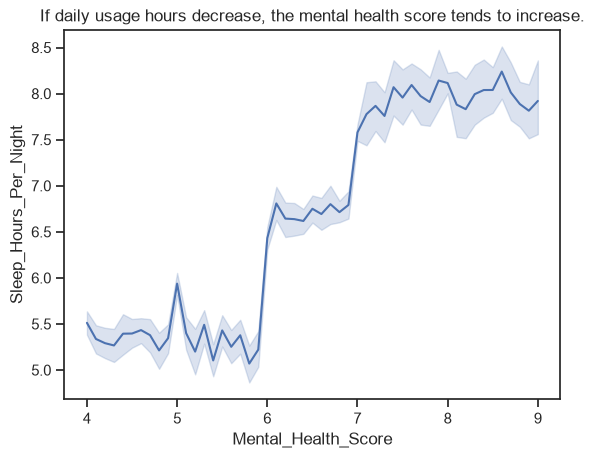

In [1470]:
sns.lineplot(x=df['Mental_Health_Score'],y=df['Sleep_Hours_Per_Night'])
plt.title('If daily usage hours decrease, the mental health score tends to increase.')

In [1471]:
df.drop(['Student_ID'],axis=1,inplace=True)

In [1472]:
df.corr(numeric_only=True)['Mental_Health_Score']

Age                      0.083701
Avg_Daily_Usage_Hours   -0.826391
Sleep_Hours_Per_Night    0.785372
Mental_Health_Score      1.000000
Name: Mental_Health_Score, dtype: float64

# Preprocessing
## OneHotEncoding

In [1473]:
df.sample(10)

,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
882,23,Male,Undergraduate,Other,6.9,Snapchat,Yes,5.7,5.7,Negative
139,20,Male,Undergraduate,Other,5.6,YouTube,Yes,5.3,5.4,Negative
513,19,Female,Graduate,India,3.8,LinkedIn,No,7.4,6.9,Neutral
601,23,Female,Undergraduate,Other,6.9,TikTok,Yes,5.9,4.6,Negative
1682,20,Female,Undergraduate,UK,6.1,Twitter,Yes,6.4,5.0,Negative
1426,20,Female,Undergraduate,USA,7.8,TikTok,Yes,4.5,5.0,Negative
1037,19,Female,High School,UAE,6.2,Instagram,Yes,5.1,5.0,Negative
1495,22,Male,Graduate,Turkey,3.8,TikTok,Yes,8.4,6.0,Negative
1537,21,Male,Graduate,Poland,3.9,Facebook,No,8.2,7.0,Positive
1447,22,Male,Graduate,Mexico,6.8,WhatsApp,Yes,5.4,6.0,Negative


In [1474]:
after_preprocessing_df=df

In [1475]:
after_preprocessing_df

,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,21,Male,Undergraduate,Other,4.0,Facebook,No,6.7,6.8,Neutral
1,23,Female,Undergraduate,Other,1.6,LinkedIn,No,8.6,7.6,Positive
2,22,Male,Graduate,Canada,4.6,Instagram,No,6.7,7.0,Neutral
3,18,Male,Undergraduate,Other,7.0,Snapchat,Yes,5.4,5.3,Negative
4,24,Female,High School,Other,7.5,Facebook,Yes,5.0,4.4,Negative
...,...,...,...,...,...,...,...,...,...,...
1700,20,Female,Undergraduate,Italy,4.7,TikTok,No,7.2,7.0,Positive
1701,23,Male,Graduate,Russia,6.8,Instagram,Yes,5.9,4.0,Negative
1702,21,Female,Undergraduate,China,5.6,WeChat,Yes,6.7,6.0,Negative
1703,24,Male,Graduate,Japan,4.3,Twitter,No,7.5,8.0,Positive


In [1476]:
gender_encoding=pd.get_dummies(after_preprocessing_df['Gender']).astype(int)
gender_encoding

,Female,Male
0,0,1
1,1,0
2,0,1
3,0,1
4,1,0
...,...,...
1700,1,0
1701,0,1
1702,1,0
1703,0,1


In [ ]:
academic_Level_labelencoding=LabelEncoder()
after_preprocessing_df['Academic_Level']=academic_Level_labelencoding.fit_transform(after_preprocessing_df['Academic_Level'])


In [1478]:
country_onehotencoder=pd.get_dummies(after_preprocessing_df['Country']).astype(int)


In [1479]:
Most_Used_Platform_onehotencder=pd.get_dummies(after_preprocessing_df['Most_Used_Platform']).astype(int)

In [1480]:
Affects_Academic_Performance_labelencoder=LabelEncoder()
after_preprocessing_df['Affects_Academic_Performance']=Affects_Academic_Performance_labelencoder.fit_transform(after_preprocessing_df['Affects_Academic_Performance'])

In [1481]:
Overall_Impact_label_encoder=LabelEncoder()
after_preprocessing_df['Overall_Impact']=Overall_Impact_label_encoder.fit_transform(after_preprocessing_df['Overall_Impact'])

In [1482]:
after_preprocessing_df.drop('Gender',axis=1,inplace=True)

In [1483]:
after_preprocessing_df=pd.concat([after_preprocessing_df,gender_encoding],axis=1)


In [1484]:
after_preprocessing_df=pd.concat([after_preprocessing_df,country_onehotencoder],axis=1)


In [1485]:
after_preprocessing_df.drop('Country',axis=1,inplace=True)

In [1486]:
after_preprocessing_df.drop('Most_Used_Platform',axis=1,inplace=True)

In [1487]:
after_preprocessing_df=pd.concat([after_preprocessing_df,Most_Used_Platform_onehotencder],axis=1)

In [1488]:
after_preprocessing_df.head()

,Age,Academic_Level,Avg_Daily_Usage_Hours,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact,Female,Male,Afghanistan,...,KakaoTalk,LINE,LinkedIn,Snapchat,TikTok,Twitter,VKontakte,WeChat,WhatsApp,YouTube
0,21,2,4.0,0,6.7,6.8,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,23,2,1.6,0,8.6,7.6,2,1,0,0,...,0,0,1,0,0,0,0,0,0,0
2,22,0,4.6,0,6.7,7.0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,18,2,7.0,1,5.4,5.3,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
4,24,1,7.5,1,5.0,4.4,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


# Correlation

In [1489]:
correlation_df=df

In [1490]:
correlation_df.drop('Country',axis=1,inplace=True)

In [1491]:
academic_Level_labelencoding=LabelEncoder()
correlation_df['Academic_Level']=academic_Level_labelencoding.fit_transform(correlation_df['Academic_Level'])

In [1492]:
Most_Used_Platform_onehotencder=pd.get_dummies(correlation_df['Most_Used_Platform']).astype(int)

In [1493]:
Affects_Academic_Performance_labelencoder=LabelEncoder()
correlation_df['Affects_Academic_Performance']=Affects_Academic_Performance_labelencoder.fit_transform(correlation_df['Affects_Academic_Performance'])

In [1494]:

academic_Level_labelencoding=LabelEncoder()
correlation_df['Academic_Level']=academic_Level_labelencoding.fit_transform(correlation_df['Academic_Level'])


In [1495]:
df.head()

,Age,Academic_Level,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,21,2,4.0,Facebook,0,6.7,6.8,1
1,23,2,1.6,LinkedIn,0,8.6,7.6,2
2,22,0,4.6,Instagram,0,6.7,7.0,1
3,18,2,7.0,Snapchat,1,5.4,5.3,0
4,24,1,7.5,Facebook,1,5.0,4.4,0


In [1496]:
# correlation_df.drop('Gender',axis=1,inplace=True)

In [1497]:
correlation_df=pd.concat([correlation_df,gender_encoding],axis=1)

In [1498]:
correlation_df.drop('Most_Used_Platform',axis=1,inplace=True)

In [1499]:
correlation_df=pd.concat([correlation_df,Most_Used_Platform_onehotencder],axis=1)

In [1500]:
correlation_df.head()

,Age,Academic_Level,Avg_Daily_Usage_Hours,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact,Female,Male,Facebook,...,KakaoTalk,LINE,LinkedIn,Snapchat,TikTok,Twitter,VKontakte,WeChat,WhatsApp,YouTube
0,21,2,4.0,0,6.7,6.8,1,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,23,2,1.6,0,8.6,7.6,2,1,0,0,...,0,0,1,0,0,0,0,0,0,0
2,22,0,4.6,0,6.7,7.0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,18,2,7.0,1,5.4,5.3,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
4,24,1,7.5,1,5.0,4.4,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0


In [1501]:
correlation_df.corr()

,Age,Academic_Level,Avg_Daily_Usage_Hours,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact,Female,Male,Facebook,...,KakaoTalk,LINE,LinkedIn,Snapchat,TikTok,Twitter,VKontakte,WeChat,WhatsApp,YouTube
Age,1.000000,-0.287922,-0.053610,-0.068873,0.063745,0.083701,0.090528,-0.133088,0.133088,0.072742,...,-0.040614,-0.088503,0.023833,0.011381,-0.038972,0.020961,0.055163,0.036721,0.019437,0.028283
Academic_Level,-0.287922,1.000000,0.033344,-0.007751,-0.041804,-0.031758,-0.013494,0.308576,-0.308576,-0.116988,...,0.089730,0.089730,-0.039424,0.033215,0.065560,0.017888,-0.099614,-0.069094,-0.131130,-0.003598
Avg_Daily_Usage_Hours,-0.053610,0.033344,1.000000,0.510700,-0.817444,-0.826391,-0.779452,0.029879,-0.029879,-0.042036,...,-0.019010,-0.093066,-0.087760,0.048870,0.063457,0.011419,-0.042859,-0.008070,0.148005,0.008163
Affects_Academic_Performance,-0.068873,-0.007751,0.510700,1.000000,-0.501297,-0.595007,-0.699069,0.001482,-0.001482,-0.126324,...,0.069754,-0.101615,-0.111285,0.023879,0.161201,-0.031094,-0.101615,-0.011435,0.149840,-0.031653
Sleep_Hours_Per_Night,0.063745,-0.041804,-0.817444,-0.501297,1.000000,0.785372,0.747814,-0.024054,0.024054,0.091478,...,0.031486,0.122187,0.037904,-0.104140,-0.089328,-0.038417,0.080325,0.059437,-0.109159,-0.046668
Mental_Health_Score,0.083701,-0.031758,-0.826391,-0.595007,0.785372,1.000000,0.848988,-0.040922,0.040922,0.069561,...,-0.014125,0.117187,0.100928,-0.040093,-0.100197,0.020804,0.051531,0.018480,-0.095636,-0.000923
Overall_Impact,0.090528,-0.013494,-0.779452,-0.699069,0.747814,0.848988,1.000000,-0.011425,0.011425,0.121209,...,-0.070872,0.024651,0.114650,-0.027212,-0.156345,0.046356,0.120174,0.020459,-0.152242,0.021564
Female,-0.133088,0.308576,0.029879,0.001482,-0.024054,-0.040922,-0.011425,1.000000,-1.000000,-0.105691,...,0.086747,0.086747,-0.024561,-0.026062,0.033854,-0.001792,-0.081709,-0.041166,-0.101807,-0.004097
Male,0.133088,-0.308576,-0.029879,-0.001482,0.024054,0.040922,0.011425,-1.000000,1.000000,0.105691,...,-0.086747,-0.086747,0.024561,0.026062,-0.033854,0.001792,0.081709,0.041166,0.101807,0.004097
Facebook,0.072742,-0.116988,-0.042036,-0.126324,0.091478,0.069561,0.121209,-0.105691,0.105691,1.000000,...,-0.035387,-0.035387,-0.142606,-0.130069,-0.192259,-0.139880,-0.035387,-0.039599,-0.076017,-0.137584


<Figure size 1000x200 with 0 Axes>

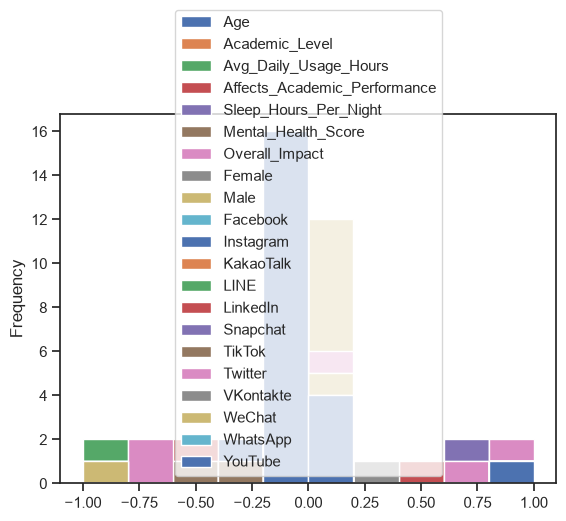

In [1502]:
correlation_df.corr().plot(kind='hist')
plt.Figure(figsize=(10,2))

In [1503]:
df.sample(5)

,Age,Academic_Level,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
795,20,2,4.2,Snapchat,0,6.2,6.7,1
680,18,0,6.3,Facebook,1,4.8,5.0,0
1017,19,1,5.0,Instagram,1,5.7,5.0,0
1333,21,0,5.9,WhatsApp,1,6.4,5.0,0
138,18,0,4.0,LinkedIn,0,6.9,6.1,1


In [1504]:
logistic_x=after_preprocessing_df.drop(['Overall_Impact'],axis=1)
# logistic_x=after_preprocessing_df.drop(['Mental_Health_Score'],axis=1)
logistic_x

,Age,Academic_Level,Avg_Daily_Usage_Hours,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Female,Male,Afghanistan,Albania,...,KakaoTalk,LINE,LinkedIn,Snapchat,TikTok,Twitter,VKontakte,WeChat,WhatsApp,YouTube
0,21,2,4.0,0,6.7,6.8,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,23,2,1.6,0,8.6,7.6,1,0,0,0,...,0,0,1,0,0,0,0,0,0,0
2,22,0,4.6,0,6.7,7.0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,18,2,7.0,1,5.4,5.3,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0
4,24,1,7.5,1,5.0,4.4,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1700,20,2,4.7,0,7.2,7.0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1701,23,0,6.8,1,5.9,4.0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1702,21,2,5.6,1,6.7,6.0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1703,24,0,4.3,0,7.5,8.0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0


In [1505]:
logistic_y=after_preprocessing_df['Overall_Impact']
# logistic_y=after_preprocessing_df['Mental_Health_Score']
logistic_y

0       1
1       2
2       1
3       0
4       0
       ..
1700    2
1701    0
1702    0
1703    2
1704    0
Name: Overall_Impact, Length: 1705, dtype: int64

# StandardScaler

In [1506]:


logistic_sc=StandardScaler()
logistic_x_scale=logistic_sc.fit_transform(logistic_x)


# Splitting Data

In [1507]:
x_train,x_test,y_train,y_test=train_test_split(logistic_x_scale,logistic_y,test_size=0.3,random_state=42)

In [1508]:
x_train

array([[-1.05122351,  1.06580354, -1.31415313, ..., -0.09421114,
        -0.18085201, -0.32732684],
       [ 0.65522151, -1.18320022, -0.24071122, ..., -0.09421114,
        -0.18085201, -0.32732684],
       [-1.05122351,  1.06580354, -0.65816085, ..., -0.09421114,
        -0.18085201, -0.32732684],
       ...,
       [ 1.79285153, -1.18320022,  1.25018033, ..., -0.09421114,
        -0.18085201,  3.05505046],
       [ 0.65522151, -1.18320022, -0.65816085, ..., -0.09421114,
        -0.18085201, -0.32732684],
       [-1.05122351,  1.06580354,  0.3556454 , ..., -0.09421114,
        -0.18085201, -0.32732684]], shape=(1193, 131))

In [1509]:
y_train

780     2
654     1
1324    2
1658    0
1493    0
       ..
1130    2
1294    2
860     0
1459    0
1126    0
Name: Overall_Impact, Length: 1193, dtype: int64

In [1510]:
x_test

array([[-1.05122351,  1.06580354, -0.18107556, ..., -0.09421114,
        -0.18085201, -0.32732684],
       [-1.62003852,  1.06580354, -1.55269578, ..., -0.09421114,
        -0.18085201, -0.32732684],
       [ 0.65522151,  1.06580354,  1.66762997, ..., -0.09421114,
        -0.18085201, -0.32732684],
       ...,
       [ 1.79285153,  1.06580354, -1.13524615, ..., -0.09421114,
        -0.18085201, -0.32732684],
       [-1.05122351,  1.06580354, -0.24071122, ..., -0.09421114,
        -0.18085201, -0.32732684],
       [ 1.79285153, -1.18320022, -2.02978108, ..., -0.09421114,
        -0.18085201, -0.32732684]], shape=(512, 131))

In [1511]:
y_test

1046    0
745     2
785     0
367     2
1029    0
       ..
867     1
974     0
327     2
1629    2
254     2
Name: Overall_Impact, Length: 512, dtype: int64

# Model evaluation

In [1512]:
model=LogisticRegression()
model.fit(x_train,y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [1513]:
y_pred = model.predict(x_test)
y_pred

array([0, 2, 0, 2, 0, 0, 2, 0, 0, 0, 2, 1, 2, 1, 0, 0, 1, 0, 0, 0, 2, 0,
       2, 0, 0, 2, 2, 0, 0, 2, 1, 0, 0, 1, 0, 1, 2, 0, 0, 0, 0, 1, 0, 2,
       2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 2, 0, 2, 0, 2, 0, 1, 2, 1, 0, 2,
       2, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 0, 2, 0, 2, 0, 0, 2, 0,
       2, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2,
       0, 0, 1, 0, 0, 2, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 2, 0, 1, 2, 1, 0, 2, 0, 0, 2, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 2, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 2, 1, 2, 0, 1, 0, 0, 0,
       0, 0, 2, 0, 2, 2, 1, 2, 1, 2, 2, 0, 0, 0, 2, 0, 2, 0, 0, 0, 1, 0,
       0, 2, 0, 0, 1, 2, 0, 1, 2, 0, 2, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 2,
       0, 1, 1, 2, 0, 0, 2, 2, 0, 0, 1, 0, 0, 0, 0, 0, 2, 2, 2, 2, 0, 0,
       1, 2, 2, 0, 2, 2, 0, 0, 2, 2, 2, 1, 2, 2, 0, 1, 2, 0, 0, 0, 0, 1,
       0, 2, 1, 0, 1, 2, 0, 0, 2, 0, 2, 2, 0, 0, 0, 0, 0, 1, 2, 0, 1, 0,
       0, 2, 0, 1, 0, 1, 2, 0, 0, 0, 1, 0, 1, 2, 0,

In [1514]:
lr_accuracy=accuracy_score(y_test,y_pred)

lr_accuracy

0.953125

# It shows how a machine learning classification model makes predictions.

Text(0.5, 1.0, 'It shows how a machine learning classification model makes predictions.')

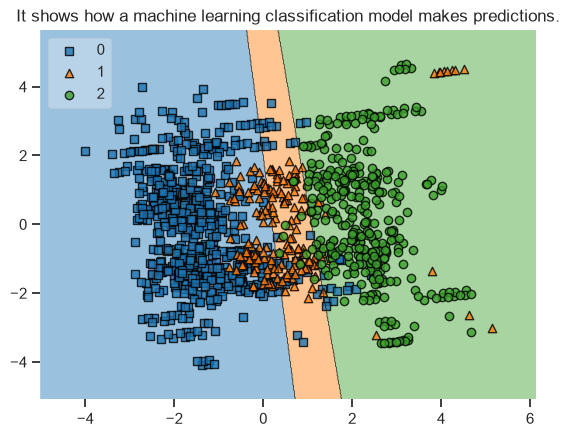

In [1515]:
from mlxtend.plotting import plot_decision_regions
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(x_train)

model.fit(X_train_pca, y_train)

plot_decision_regions(
    X_train_pca,
    y_train.values,
    clf=model,
    legend=2
)
plt.title('It shows how a machine learning classification model makes predictions.')


In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score



print("MAE:", mean_absolute_error(y_test,y_pred))
print("MSE:", mean_squared_error(y_test,y_pred))
print("RMSE:", mean_squared_error(y_test,y_pred) ** 0.5)
print("R2 Score:", r2_score(y_test,y_pred))

MAE: 0.0546875
MSE: 0.0703125
RMSE: 0.2651650429449553
R2 Score: 0.9078800721686067


# 2 Linear Regression

In [1517]:
# lr_x=after_preprocessing_df.drop('Mental_Health_Score',axis=1).astype(int)
lr_x=after_preprocessing_df.drop(['Overall_Impact','Mental_Health_Score'],axis=1)

# lr_y=after_preprocessing_df['Mental_Health_Score'].astype(int)
lr_y=after_preprocessing_df[['Overall_Impact','Mental_Health_Score']]

In [1518]:
sc=StandardScaler()
lr_scale_x=sc.fit_transform(lr_x)
lr_scale_x

array([[ 0.0864065 ,  1.06580354, -0.65816085, ..., -0.09421114,
        -0.18085201, -0.32732684],
       [ 1.22403652,  1.06580354, -2.08941674, ..., -0.09421114,
        -0.18085201, -0.32732684],
       [ 0.65522151, -1.18320022, -0.30034688, ..., -0.09421114,
        -0.18085201, -0.32732684],
       ...,
       [ 0.0864065 ,  1.06580354,  0.29600974, ..., 10.61445555,
        -0.18085201, -0.32732684],
       [ 1.79285153, -1.18320022, -0.47925387, ..., -0.09421114,
        -0.18085201, -0.32732684],
       [-1.05122351,  1.06580354,  0.65382371, ..., -0.09421114,
        -0.18085201, -0.32732684]], shape=(1705, 130))

In [1519]:
# lr_scale_y=sc.fit_transform(lr_y)
# lr_scale_y
lr_y

,Overall_Impact,Mental_Health_Score
0,1,6.8
1,2,7.6
2,1,7.0
3,0,5.3
4,0,4.4
...,...,...
1700,2,7.0
1701,0,4.0
1702,0,6.0
1703,2,8.0


In [1520]:
lr_x_train,lr_x_test,lr_y_train,lr_y_test=train_test_split(lr_scale_x,lr_y,test_size=0.3,random_state=42)

In [1521]:
lr_x_train

array([[-1.05122351,  1.06580354, -1.31415313, ..., -0.09421114,
        -0.18085201, -0.32732684],
       [ 0.65522151, -1.18320022, -0.24071122, ..., -0.09421114,
        -0.18085201, -0.32732684],
       [-1.05122351,  1.06580354, -0.65816085, ..., -0.09421114,
        -0.18085201, -0.32732684],
       ...,
       [ 1.79285153, -1.18320022,  1.25018033, ..., -0.09421114,
        -0.18085201,  3.05505046],
       [ 0.65522151, -1.18320022, -0.65816085, ..., -0.09421114,
        -0.18085201, -0.32732684],
       [-1.05122351,  1.06580354,  0.3556454 , ..., -0.09421114,
        -0.18085201, -0.32732684]], shape=(1193, 130))

In [1522]:
lr_model=LinearRegression()


In [1523]:
lr_y_pred=lr_model.fit(lr_x_train,lr_y_train)

In [1524]:
lr_y_pred

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2, 130)","[[ 0.01, 0.03,-0.35,..., 0.07, 0.01, 0.01], [ 0.01,-0.01,-0.6 ,...,-0. , 0.02,-0.01]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](2,)","[0.74,6.23]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,130
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(108)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](130,)","[58.77,57.19,48.69,..., 0. , 0. , 0. ]"


In [1525]:
lr_y_pred=lr_model.predict(lr_x_test)
lr_y_pred

array([[ 0.44071943,  5.87024794],
       [ 1.83700364,  7.77437367],
       [-0.11512023,  4.74594615],
       ...,
       [ 1.84737652,  7.74758986],
       [ 1.45298649,  6.37894995],
       [ 2.17488673,  8.55367476]], shape=(512, 2))

In [1526]:
lr_x_test

array([[-1.05122351,  1.06580354, -0.18107556, ..., -0.09421114,
        -0.18085201, -0.32732684],
       [-1.62003852,  1.06580354, -1.55269578, ..., -0.09421114,
        -0.18085201, -0.32732684],
       [ 0.65522151,  1.06580354,  1.66762997, ..., -0.09421114,
        -0.18085201, -0.32732684],
       ...,
       [ 1.79285153,  1.06580354, -1.13524615, ..., -0.09421114,
        -0.18085201, -0.32732684],
       [-1.05122351,  1.06580354, -0.24071122, ..., -0.09421114,
        -0.18085201, -0.32732684],
       [ 1.79285153, -1.18320022, -2.02978108, ..., -0.09421114,
        -0.18085201, -0.32732684]], shape=(512, 130))

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

lr_mean_absolute_error= mean_absolute_error(lr_y_test, lr_y_pred)
lr_mean_absolute_erro=mean_squared_error(lr_y_test, lr_y_pred)
lr_r2_score=r2_score(lr_y_test, lr_y_pred)

print("lr_MAE:",lr_mean_absolute_error)
print("Lr_MSE:", lr_mean_absolute_erro)
print("Lr_RMSE:", mean_squared_error(lr_y_test, lr_y_pred) ** 0.5)
print("Lr_R2 Score:",lr_r2_score)


MAE: 0.37919387131152293
MSE: 0.24864586773283098
RMSE: 0.4986440290756834
R2 Score: 0.8035712139664392


### When apply fittransform on dependent feature
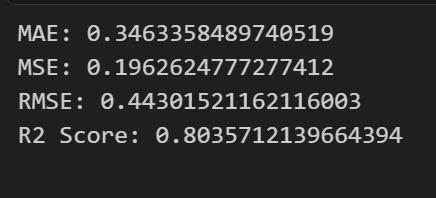

# 3 K-Mean Algorithm 

In [1528]:
from sklearn.cluster import KMeans

In [1529]:
k_mean_df=after_preprocessing_df

In [1530]:
df.head()

,Age,Academic_Level,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,21,2,4.0,Facebook,0,6.7,6.8,1
1,23,2,1.6,LinkedIn,0,8.6,7.6,2
2,22,0,4.6,Instagram,0,6.7,7.0,1
3,18,2,7.0,Snapchat,1,5.4,5.3,0
4,24,1,7.5,Facebook,1,5.0,4.4,0


In [1531]:
k_mean_x=k_mean_df.drop('Overall_Impact',axis=1)
k_mean_y=k_mean_df['Overall_Impact']

In [1532]:
k_mean_x

,Age,Academic_Level,Avg_Daily_Usage_Hours,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Female,Male,Afghanistan,Albania,...,KakaoTalk,LINE,LinkedIn,Snapchat,TikTok,Twitter,VKontakte,WeChat,WhatsApp,YouTube
0,21,2,4.0,0,6.7,6.8,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,23,2,1.6,0,8.6,7.6,1,0,0,0,...,0,0,1,0,0,0,0,0,0,0
2,22,0,4.6,0,6.7,7.0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,18,2,7.0,1,5.4,5.3,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0
4,24,1,7.5,1,5.0,4.4,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1700,20,2,4.7,0,7.2,7.0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1701,23,0,6.8,1,5.9,4.0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1702,21,2,5.6,1,6.7,6.0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1703,24,0,4.3,0,7.5,8.0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0


In [1533]:
k_mean_y

0       1
1       2
2       1
3       0
4       0
       ..
1700    2
1701    0
1702    0
1703    2
1704    0
Name: Overall_Impact, Length: 1705, dtype: int64

In [1534]:
k_x_scale=sc.fit_transform(k_mean_x)
k_x_scale

array([[ 0.0864065 ,  1.06580354, -0.65816085, ..., -0.09421114,
        -0.18085201, -0.32732684],
       [ 1.22403652,  1.06580354, -2.08941674, ..., -0.09421114,
        -0.18085201, -0.32732684],
       [ 0.65522151, -1.18320022, -0.30034688, ..., -0.09421114,
        -0.18085201, -0.32732684],
       ...,
       [ 0.0864065 ,  1.06580354,  0.29600974, ..., 10.61445555,
        -0.18085201, -0.32732684],
       [ 1.79285153, -1.18320022, -0.47925387, ..., -0.09421114,
        -0.18085201, -0.32732684],
       [-1.05122351,  1.06580354,  0.65382371, ..., -0.09421114,
        -0.18085201, -0.32732684]], shape=(1705, 131))

In [1535]:
k_x_train,k_x_test,k_y_train,k_y_test=train_test_split(k_x_scale,k_mean_y,test_size=0.3,random_state=42)

In [1536]:
k_mean_model=KMeans()

k_mean_y_pred=k_mean_model.fit(k_x_train,k_y_train)
k_mean_y_pred=k_mean_model.predict(k_x_test)
k_mean_y_pred

array([3, 1, 3, 4, 3, 3, 1, 4, 3, 3, 1, 3, 0, 1, 3, 3, 3, 3, 3, 3, 1, 3,
       4, 3, 3, 1, 1, 3, 0, 1, 1, 1, 4, 1, 4, 1, 1, 3, 3, 3, 3, 1, 3, 1,
       1, 3, 1, 3, 3, 4, 3, 3, 3, 3, 1, 1, 3, 1, 4, 1, 4, 3, 1, 3, 3, 1,
       1, 4, 3, 1, 3, 4, 3, 3, 3, 3, 1, 3, 1, 1, 3, 1, 0, 1, 3, 1, 1, 3,
       1, 3, 4, 4, 0, 3, 3, 4, 3, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 1, 3, 1,
       3, 3, 3, 3, 1, 1, 3, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 3, 3,
       3, 1, 3, 3, 1, 1, 3, 1, 3, 4, 1, 3, 4, 1, 3, 3, 3, 3, 1, 3, 3, 4,
       3, 1, 3, 1, 1, 3, 3, 3, 3, 3, 3, 1, 3, 3, 1, 3, 1, 3, 3, 3, 3, 3,
       3, 3, 1, 3, 1, 1, 1, 1, 3, 4, 1, 3, 3, 3, 1, 4, 1, 3, 3, 3, 3, 3,
       1, 4, 3, 3, 3, 1, 3, 1, 1, 4, 1, 4, 3, 1, 4, 3, 0, 1, 3, 4, 3, 1,
       4, 3, 3, 1, 3, 3, 1, 1, 3, 3, 3, 3, 3, 3, 3, 4, 1, 1, 1, 1, 3, 4,
       0, 0, 1, 3, 1, 1, 3, 3, 1, 4, 1, 1, 1, 1, 3, 1, 1, 3, 3, 4, 3, 1,
       3, 1, 1, 4, 1, 1, 3, 3, 1, 3, 1, 1, 3, 3, 3, 3, 3, 4, 1, 3, 3, 3,
       3, 0, 3, 3, 3, 3, 1, 3, 3, 3, 3, 3, 3, 1, 3,

In [ ]:
k_mean_accuracy=accuracy_score(k_y_test,k_mean_y_pred)
k_mean_mae=mean_absolute_error(k_y_test,k_mean_y_pred)
k_mean_mse=mean_squared_error(k_y_test,k_mean_y_pred)


Accuracy 0.076171875
MEA 2.1796875
MSE 6.12109375


# NAIVE BAYES ALGORITHM

In [1539]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [1540]:
k_x_train,k_x_test,k_y_train,k_y_test=train_test_split(k_x_scale,k_mean_y,test_size=0.3,random_state=42)

In [1541]:
naive_bayes_model=GaussianNB()

k_mean_y_pred=naive_bayes_model.fit(k_x_train,k_y_train)
k_mean_y_pred=naive_bayes_model.predict(k_x_test)
k_mean_y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 2, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 2, 1, 0, 2,
       1, 1, 1, 1, 2, 0, 1, 1, 1, 1, 1, 1, 2, 2, 1, 2, 1, 2, 1, 0, 1, 2,
       1, 1, 2, 1, 1, 1, 1, 0, 1, 2, 1, 0, 1, 1, 1, 1, 2, 2, 2, 1, 0, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 2, 2, 1, 0, 1, 0, 1, 0, 1, 1, 1, 2, 1, 2, 1, 1, 0, 0, 1,
       1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       2, 1, 1, 0, 1, 2, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 2,
       2, 1, 1, 1, 1, 0, 2, 1, 1, 1, 1, 0, 1, 1, 2, 1, 1, 2, 2, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 2, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 2, 1,

In [1542]:
accuracy=accuracy_score(k_y_test,k_mean_y_pred)
mae=mean_absolute_error(k_y_test,k_mean_y_pred)
mse=mean_squared_error(k_y_test,k_mean_y_pred)

In [1543]:
print('Accuracy',accuracy)
print('MEA',mae)
print('MSE',mse)

Accuracy 0.3828125
MEA 0.666015625
MSE 0.763671875


In [1544]:
cm=confusion_matrix(k_y_test,k_mean_y_pred)
print('CM :',cm)

CM : [[ 74 193  23]
 [  0  79   0]
 [  2  98  43]]


# 5 decision_tree_model

In [1545]:
from sklearn.tree import DecisionTreeClassifier

In [1546]:
decision_tree_model=DecisionTreeClassifier( criterion="gini",max_depth=5,random_state=42)

k_mean_y_pred=decision_tree_model.fit(k_x_train,k_y_train)
k_mean_y_pred=decision_tree_model.predict(k_x_test)
k_mean_y_pred

array([0, 2, 0, 2, 0, 0, 2, 2, 0, 0, 2, 1, 1, 1, 0, 0, 1, 0, 0, 0, 2, 0,
       2, 0, 0, 2, 2, 0, 0, 2, 2, 0, 0, 1, 0, 1, 2, 0, 0, 0, 0, 1, 0, 2,
       2, 0, 2, 0, 0, 0, 1, 0, 0, 0, 1, 2, 0, 2, 0, 2, 1, 1, 2, 1, 0, 2,
       2, 0, 0, 2, 0, 2, 0, 0, 0, 0, 2, 0, 2, 2, 0, 2, 0, 2, 0, 0, 2, 0,
       2, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2,
       0, 0, 1, 0, 0, 2, 0, 2, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 2, 0, 1, 2, 1, 0, 2, 0, 0, 2, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 2, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 2, 1, 2, 0, 1, 0, 0, 0,
       1, 0, 2, 0, 2, 2, 1, 2, 1, 2, 2, 0, 0, 0, 2, 0, 2, 0, 0, 0, 1, 0,
       2, 2, 0, 0, 1, 2, 0, 1, 2, 0, 2, 1, 0, 2, 0, 0, 0, 2, 0, 1, 0, 2,
       0, 1, 1, 2, 0, 0, 2, 2, 0, 0, 1, 0, 0, 0, 0, 1, 2, 2, 2, 2, 0, 0,
       1, 2, 2, 0, 2, 2, 0, 0, 2, 2, 2, 1, 2, 2, 0, 1, 2, 0, 0, 0, 1, 1,
       0, 2, 2, 0, 1, 2, 0, 0, 2, 0, 2, 2, 0, 0, 0, 0, 0, 2, 2, 0, 1, 0,
       0, 2, 0, 1, 0, 1, 2, 0, 0, 0, 1, 0, 1, 2, 0,

In [1547]:
print("MAE:", mean_absolute_error(k_y_test,k_mean_y_pred))
print("MSE:", mean_squared_error(k_y_test,k_mean_y_pred))
print("RMSE:", mean_squared_error(k_y_test,k_mean_y_pred) ** 0.5)
print("R2 Score:", r2_score(k_y_test,k_mean_y_pred))

MAE: 0.052734375
MSE: 0.095703125
RMSE: 0.30935921676911454
R2 Score: 0.8746145426739369


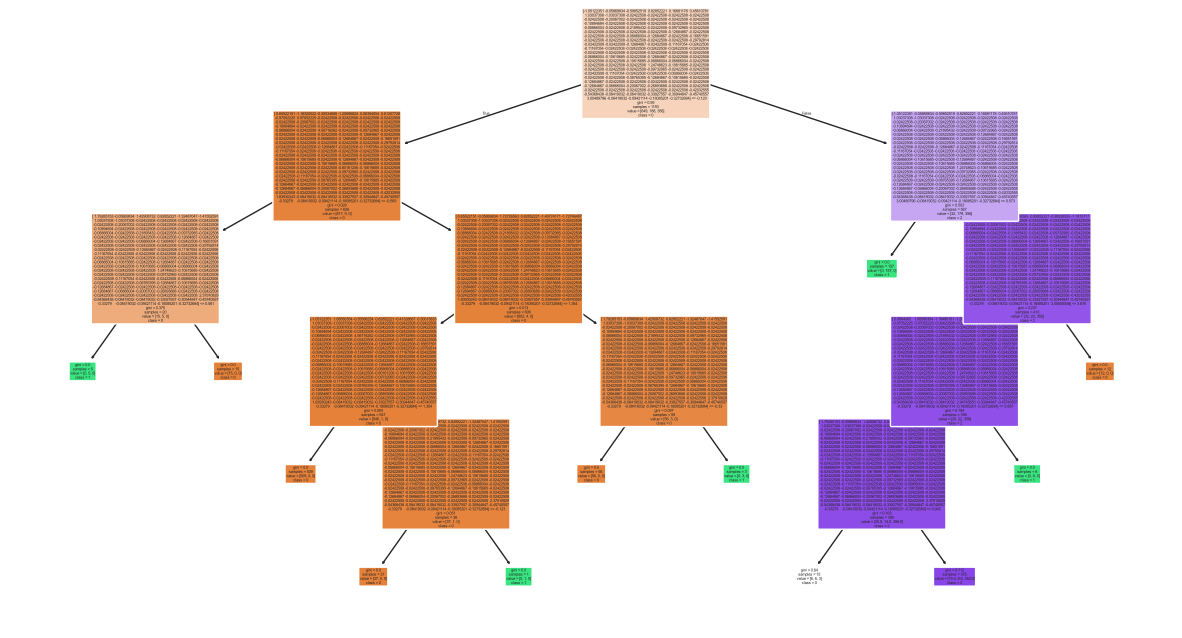

In [1548]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 8))

plot_tree(
    decision_tree_model,
    feature_names=k_x_scale,
    class_names=decision_tree_model.classes_.astype(str),
    filled=True,
    rounded=True
)

plt.show()

# Linar Model

In [1554]:
print("lr_MAE:",lr_mean_absolute_error)
print("Lr_MSE:", lr_mean_absolute_erro)
print("Lr_RMSE:", mean_squared_error(lr_y_test, lr_y_pred) ** 0.5)
print("Lr_R2 Score:",lr_r2_score)

lr_MAE: 0.37919387131152293
Lr_MSE: 0.24864586773283098
Lr_RMSE: 0.4986440290756834
Lr_R2 Score: 0.8035712139664392


In [1562]:
k_mean_accuracy=accuracy_score(k_y_test,k_mean_y_pred)
k_mean_mae=mean_absolute_error(k_y_test,k_mean_y_pred)
k_mean_mse=mean_squared_error(k_y_test,k_mean_y_pred)


print("k_mean_accuracy:",k_mean_accuracy)
print("k_mean_mae: ",k_mean_mae)
print("k_mean_mse:",k_mean_mse)



k_mean_accuracy: 0.96875
k_mean_mae:  0.052734375
k_mean_mse: 0.095703125


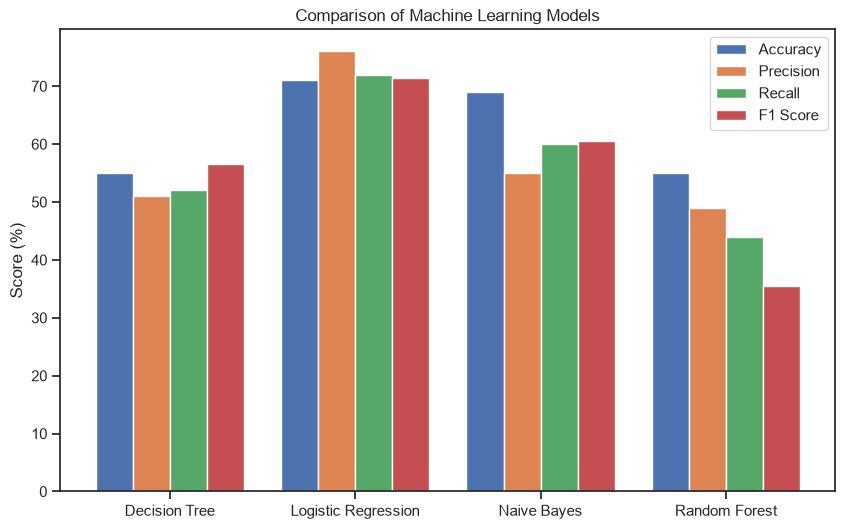

In [1564]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Decision Tree', 'Logistic Regression', 'Naive Bayes', 'Random Forest']

accuracy = [55, 71, 69, 55]
precision = [51, 76, 55, 49]
recall = [52, 72, 60, 44]
f1 = [56.5, 71.5, 60.5, 35.5]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(10,6))

plt.bar(x - 1.5*width, accuracy, width, label='Accuracy')
plt.bar(x - 0.5*width, precision, width, label='Precision')
plt.bar(x + 0.5*width, recall, width, label='Recall')
plt.bar(x + 1.5*width, f1, width, label='F1 Score')

plt.xticks(x, models)
plt.ylabel("Score (%)")
plt.title("Comparison of Machine Learning Models")
plt.legend()

plt.show()